#**Código Python: Unidade 2**

# **Passo 1: Configurar o ambiente**
###Instalando a Biblioteca para análise de Sobrevivência





In [2]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ec43aa1f1b6806d50775f5ed995fdd3dc128c73db59878e269b3e560ddb6e20e
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


###Importando as funções

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import ExponentialFitter, KaplanMeierFitter

# **Passo 2: Código Python**

#**Exemplo: Modelo Exponencial**
##Cenário: Uma empresa registrou os tempos (em horas) até a falha de 10 máquinas industriais. Parte dos dados está censurada porque algumas máquinas ainda não falharam até o final do período de observação.

###Inserir dados

In [ ]:
# Dados simulados: tempos até a falha (em horas)
data = {
    'time': [5, 8, 12, 20, 25, 30, 50, 70, 100, 150],  # Tempos observados
    'event': [1, 1, 1, 1, 1, 0, 1, 0, 0, 0]  # 1 = Falha observada, 0 = Censurado
}

# Criar um DataFrame
df = pd.DataFrame(data)
print(df)

   time  event
0     5      1
1     8      1
2    12      1
3    20      1
4    25      1
5    30      0
6    50      1
7    70      0
8   100      0
9   150      0


###Ajuste do Modelo Exponencial

In [ ]:
# Ajustar o modelo exponencial
exp_fitter = ExponentialFitter()
exp_fitter.fit(df['time'], event_observed=df['event'])

# Exibir os parâmetros do modelo
print("\nParâmetros do modelo exponencial:")
print(exp_fitter.summary)


Parâmetros do modelo exponencial:
              coef   se(coef)  coef lower 95%  coef upper 95%  cmp to  \
lambda_  78.333301  31.979423       15.654784      141.011818     0.0   

                z         p  -log2(p)  
lambda_  2.449491  0.014306  6.127252  


###Estimando a Função de Sobrevivência S(t) pelo Método Exponencial

###Probabilidade Estimada de Sobrevivência no tempo t

In [ ]:
print(exp_fitter.survival_function_)

            Exponential_estimate
5.000000                0.938165
21.111111               0.763758
37.222222               0.621775
53.333333               0.506186
69.444444               0.412085
85.555556               0.335478
101.666667              0.273112
117.777778              0.222340
133.888889              0.181007
150.000000              0.147357


###Gráfico da Função de Sobrevivência

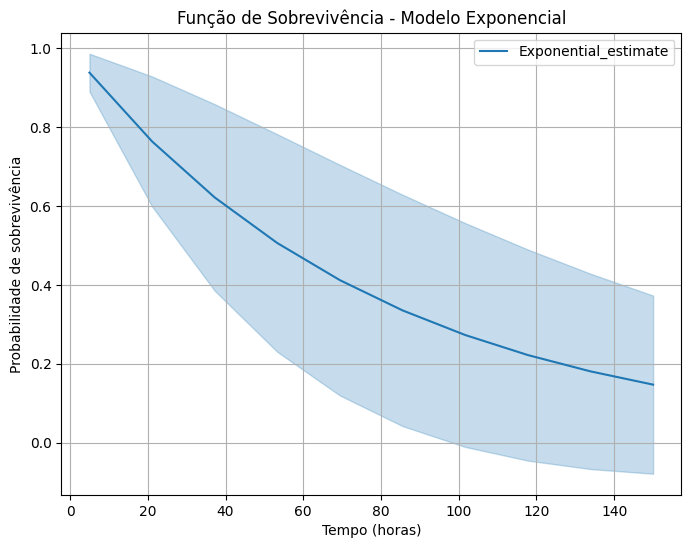

In [ ]:
# Plotar a função de sobrevivência
plt.figure(figsize=(8, 6))
exp_fitter.plot_survival_function()
plt.title('Função de Sobrevivência - Modelo Exponencial')
plt.xlabel('Tempo (horas)')
plt.ylabel('Probabilidade de sobrevivência')
plt.grid()
plt.show()

###Função de risco

In [ ]:
# Função de risco constante para o modelo exponencial
lambda_param = exp_fitter.lambda_  # Taxa de falha
print(f"\nFunção de risco (constante para modelo exponencial): {lambda_param:.4f}")


Função de risco (constante para modelo exponencial): 78.3333


###Gráfico da Função de Risco

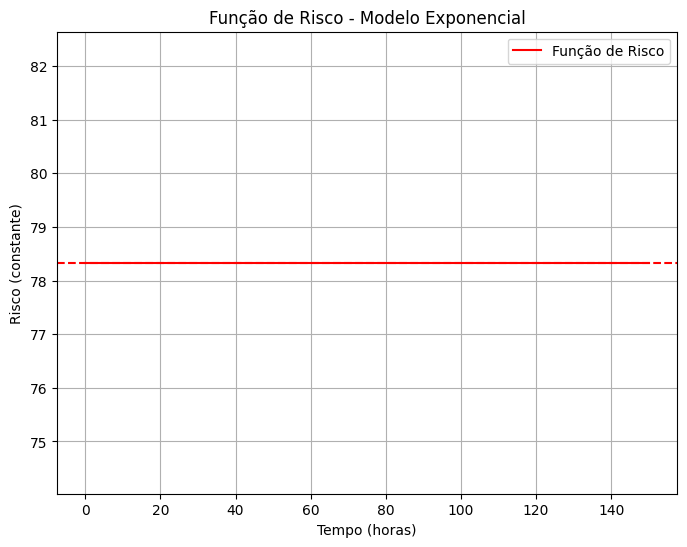

In [ ]:
# Plotar a função de risco (constante para o modelo exponencial)
plt.figure(figsize=(8, 6))
tempos = np.linspace(0, 150, 100)
risco = np.full_like(tempos, lambda_param)
plt.plot(tempos, risco, label='Função de Risco', color='red')
plt.title('Função de Risco - Modelo Exponencial')
plt.xlabel('Tempo (horas)')
plt.ylabel('Risco (constante)')
plt.axhline(y=lambda_param, color='red', linestyle='--')
plt.grid()
plt.legend()
plt.show()

###Adequação do modelo

###Comparação da Função de Sobrevivência vs Kaplan-Meier

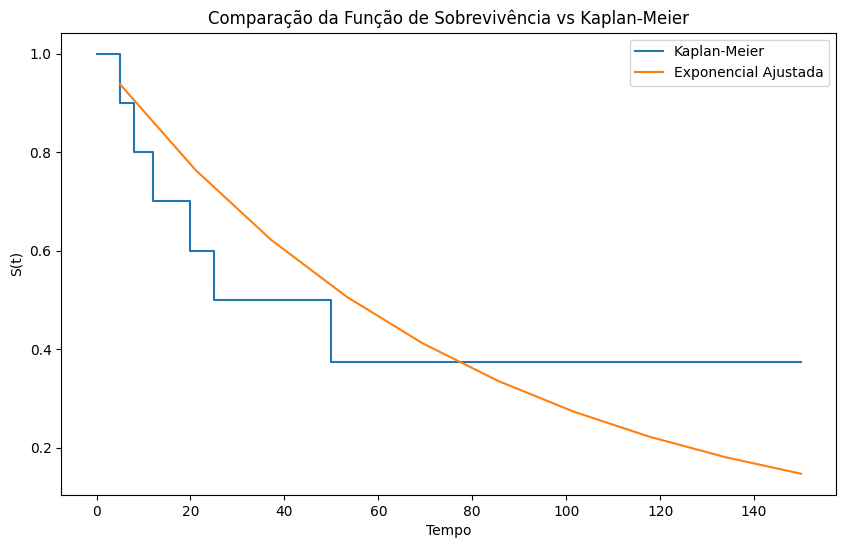

In [ ]:
# Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(data['time'], event_observed=data['event'])
# Gráfico de sobrevivência empírica e ajustada
plt.figure(figsize=(10, 6))
kmf.plot_survival_function(ci_show=False, label='Kaplan-Meier')
exp_fitter.plot_survival_function(ci_show=False, label='Exponencial Ajustada')
plt.title('Comparação da Função de Sobrevivência vs Kaplan-Meier')
plt.xlabel('Tempo')
plt.ylabel('S(t)')
plt.legend()
plt.show()

###Gráfico do risco Acumulado

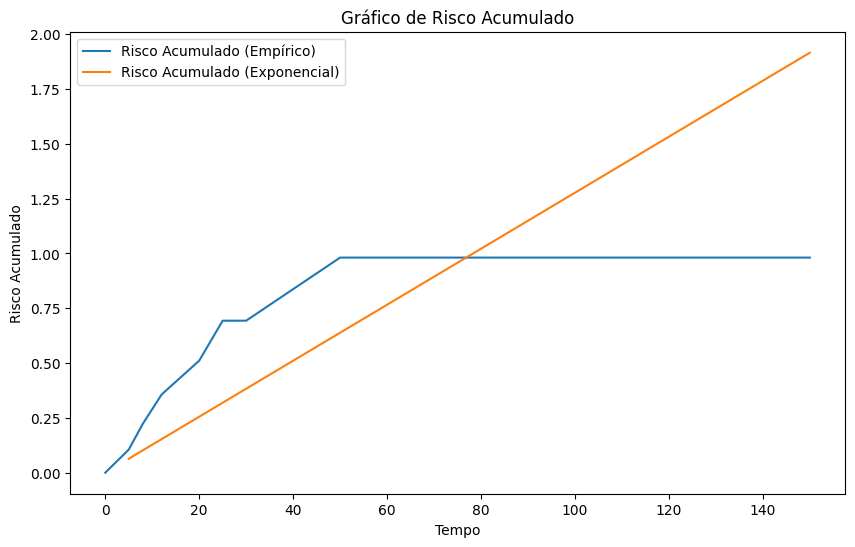

In [ ]:
# Risco acumulado
plt.figure(figsize=(10, 6))
plt.plot(kmf.event_table.index, -np.log(kmf.survival_function_['KM_estimate']), label='Risco Acumulado (Empírico)')
plt.plot(data['time'], exp_fitter.cumulative_hazard_at_times(data['time']), label='Risco Acumulado (Exponencial)')
plt.title('Gráfico de Risco Acumulado')
plt.xlabel('Tempo')
plt.ylabel('Risco Acumulado')
plt.legend()
plt.show()

###Gráfico Lo-log para o modelo Exponencial

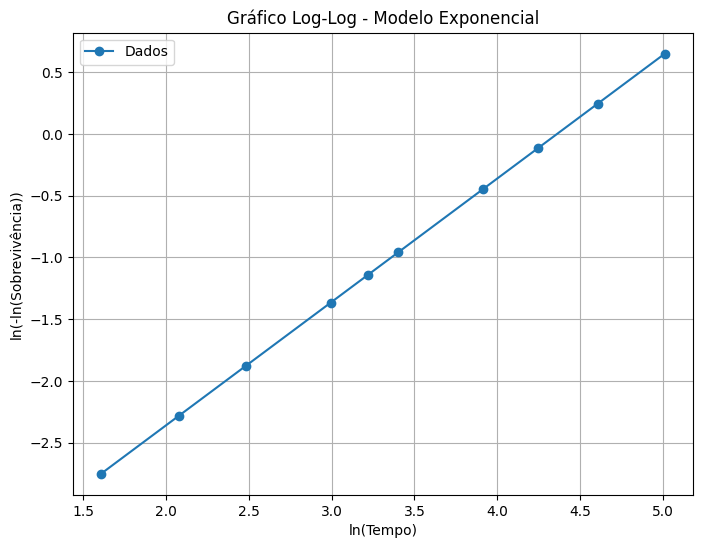

In [ ]:
# Função de sobrevivência ajustada pelo modelo Exponencial
sobrevivencia = exp_fitter.survival_function_at_times(data['time'])

# Transformações para o gráfico log-log
log_tempo = np.log(data['time'])
log_neg_log_sobrevivencia = np.log(-np.log(sobrevivencia))

# Plotar gráfico log-log
plt.figure(figsize=(8, 6))
plt.plot(log_tempo, log_neg_log_sobrevivencia, 'o-', label='Dados')
plt.title('Gráfico Log-Log - Modelo Exponencial')
plt.xlabel('ln(Tempo)')
plt.ylabel('ln(-ln(Sobrevivência))')
plt.grid()
plt.legend()
plt.show()

###Tempo médio de sobrevivência para o modelo exponencial

In [ ]:
tempo_medio_sobrevivencia = 1 / lambda_param
print(f"Tempo médio de sobrevivência: {tempo_medio_sobrevivencia:.2f} horas")


Tempo médio de sobrevivência: 0.01 horas


###Previsão de Sobrevida para o Método Exponencial

In [ ]:
# Exemplo de previsões
tempo_predicao = np.array([10, 20, 40])
predicoes = exp_fitter.survival_function_at_times(tempo_predicao)

print("\nProbabilidade de sobrevivência prevista para tempos específicos:")
for t, p in zip(tempo_predicao, predicoes):
    print(f"Tempo = {t} horas, Probabilidade de sobrevivência = {p:.2f}")



Probabilidade de sobrevivência prevista para tempos específicos:
Tempo = 10 horas, Probabilidade de sobrevivência = 0.88
Tempo = 20 horas, Probabilidade de sobrevivência = 0.77
Tempo = 40 horas, Probabilidade de sobrevivência = 0.60


#**Exemplo: Modelo Weibull**
##Cenário: Uma empresa registrou os tempos (em horas) até a falha de 10 máquinas industriais. Parte dos dados está censurada porque algumas máquinas ainda não falharam até o final do período de observação.

###Instalando a Biblioteca para análise de Sobrevivência

In [ ]:
pip install lifelines

###Importar as funções

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import WeibullFitter, KaplanMeierFitter

###Inserir os dados

In [ ]:
# Dados simulados: tempos até a falha (em horas)
data = {
    'time': [5, 8, 12, 20, 25, 30, 50, 70, 100, 150],  # Tempos observados
    'event': [1, 1, 1, 1, 1, 0, 1, 0, 0, 0]  # 1 = Falha observada, 0 = Censurado
}

# Criar um DataFrame
df = pd.DataFrame(data)
print(df)

   time  event
0     5      1
1     8      1
2    12      1
3    20      1
4    25      1
5    30      0
6    50      1
7    70      0
8   100      0
9   150      0


###Ajuste do modelo Weibull



In [ ]:
# Ajustar o modelo Weibull
weibull_fitter = WeibullFitter()
weibull_fitter.fit(df['time'], event_observed=df['event'])

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 10 total observations, 4 right-censored observations>

###Parâmetros no Método Weibull

In [ ]:
# Exibir os parâmetros do modelo
print("\nParâmetros do modelo Weibull:")
print(weibull_fitter.summary)



Parâmetros do modelo Weibull:
              coef   se(coef)  coef lower 95%  coef upper 95%  cmp to  \
lambda_  83.857050  47.575129       -9.388489      177.102589     1.0   
rho_      0.736641   0.251940        0.242848        1.230434     1.0   

                z         p  -log2(p)  
lambda_  1.741604  0.081578  3.615681  
rho_    -1.045325  0.295873  1.756951  


###Estimando a Função de Sobrevivência S(t) pelo Método Weibull


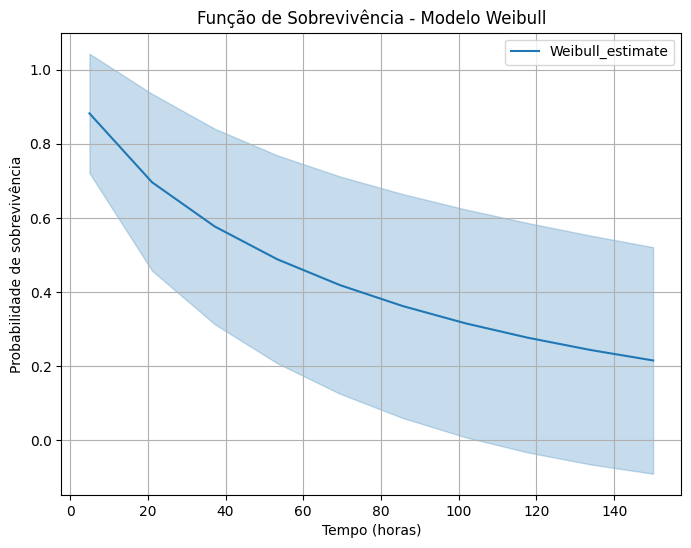

In [ ]:
# Plotar a função de sobrevivência
plt.figure(figsize=(8, 6))
weibull_fitter.plot_survival_function()
plt.title('Função de Sobrevivência - Modelo Weibull')
plt.xlabel('Tempo (horas)')
plt.ylabel('Probabilidade de sobrevivência')
plt.grid()
plt.show()

###Probabilidade Estimada de Sobrevivência no tempo t

In [ ]:
print(weibull_fitter.survival_function_)

            Weibull_estimate
5.000000            0.882237
21.111111           0.696269
37.222222           0.577098
53.333333           0.488456
69.444444           0.418827
85.555556           0.362446
101.666667          0.315870
117.777778          0.276840
133.888889          0.243771
150.000000          0.215508


###Função de risco

In [ ]:
# Calcular a função de risco
tempos_plot = np.linspace(0.1, max(tempos), 100)  # Evitar divisão por zero
risco = weibull_fitter.hazard_at_times(tempos_plot)
print(risco)

0.100000     0.051720
0.604040     0.032207
1.108081     0.027451
1.612121     0.024870
2.116162     0.023151
               ...   
47.983838    0.010176
48.487879    0.010148
48.991919    0.010120
49.495960    0.010093
50.000000    0.010066
Name: Weibull_estimate, Length: 100, dtype: float64


###Gráfico da Função de Risco

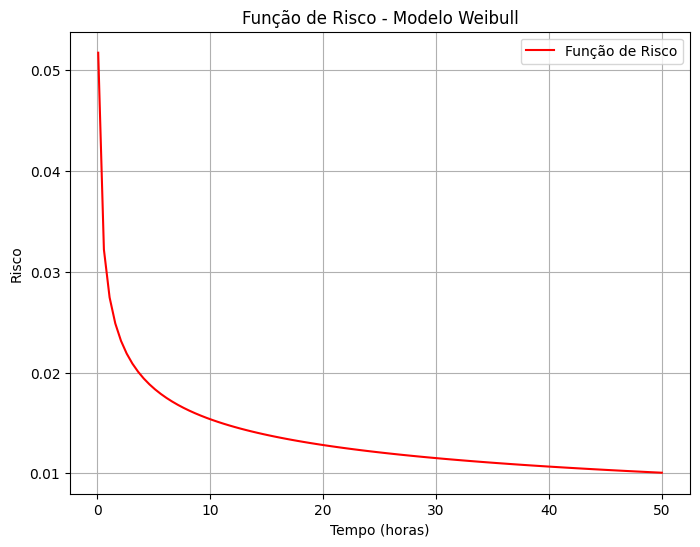

In [ ]:
# Plotar a função de risco
plt.figure(figsize=(8, 6))
plt.plot(tempos_plot, risco, label='Função de Risco', color='red')
plt.title('Função de Risco - Modelo Weibull')
plt.xlabel('Tempo (horas)')
plt.ylabel('Risco')
plt.grid()
plt.legend()
plt.show()

###Tempo Médio Esperado de Sobrevivência

In [ ]:
# Tempo médio de sobrevivência (Weibull não possui fórmula analítica direta, mas pode ser estimado numericamente)
def tempo_medio_weibull(a, b):
    from scipy.special import gamma
    return b * gamma(1 + 1/a)

shape = weibull_fitter.rho_  # Forma (shape parameter)
scale = weibull_fitter.lambda_  # Escala (scale parameter)

tempo_medio_sobrevivencia = tempo_medio_weibull(shape, scale)
print(f"\nTempo médio de sobrevivência: {tempo_medio_sobrevivencia:.2f} horas")


Tempo médio de sobrevivência: 101.36 horas


###Previsão

In [ ]:
# Previsões para tempos específicos
tempos_prev = np.array([10, 20, 40])
previsoes_sobrevivencia = weibull_fitter.survival_function_at_times(tempos_prev)

print("\nProbabilidade de sobrevivência para tempos específicos:")
for t, p in zip(tempos_prev, previsoes_sobrevivencia):
    print(f"Tempo = {t} horas, Probabilidade de sobrevivência = {p:.2f}")


Probabilidade de sobrevivência para tempos específicos:
Tempo = 10 horas, Probabilidade de sobrevivência = 0.81
Tempo = 20 horas, Probabilidade de sobrevivência = 0.71
Tempo = 40 horas, Probabilidade de sobrevivência = 0.56


###Interpretação gráfica





In [ ]:
# Interpretação gráfica
print("\nInterpretação Gráfica:")
print("1. A curva da função de sobrevivência mostra a probabilidade de o equipamento sobreviver até um determinado tempo.")
print("2. A função de risco da distribuição Weibull pode aumentar, diminuir ou ser constante, dependendo do parâmetro de forma (shape).")
print(f"   - Neste caso, o parâmetro de forma (shape) é {shape:.2f}, indicando um risco {'crescente' if shape > 1 else 'decrescente' if shape < 1 else 'constante'} ao longo do tempo.")



Interpretação Gráfica:
1. A curva da função de sobrevivência mostra a probabilidade de o equipamento sobreviver até um determinado tempo.
2. A função de risco da distribuição Weibull pode aumentar, diminuir ou ser constante, dependendo do parâmetro de forma (shape).
   - Neste caso, o parâmetro de forma (shape) é 0.74, indicando um risco decrescente ao longo do tempo.


###Adequação do modelo

###Gráfico Comparação da Função de Sobrevivência vs Kaplan-Meier

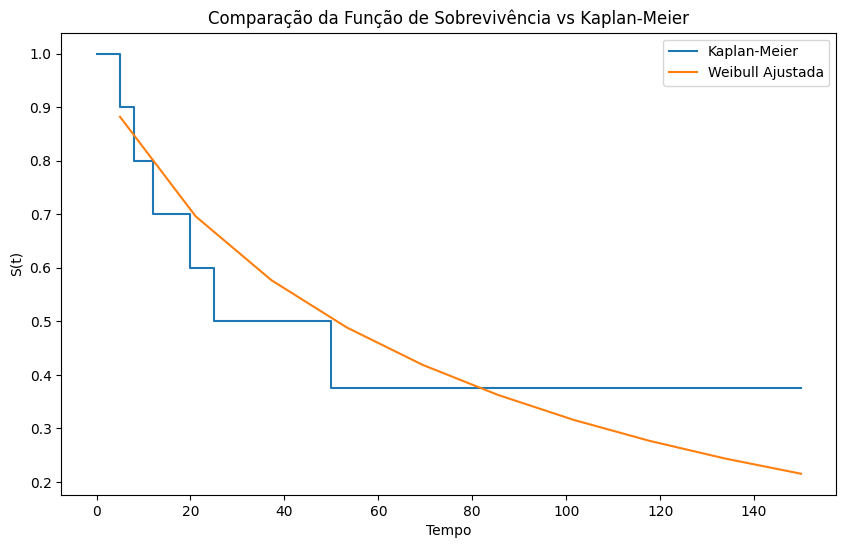

In [ ]:
# Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(data['time'], event_observed=data['event'])
# Gráfico de sobrevivência empírica e ajustada
plt.figure(figsize=(10, 6))
kmf.plot_survival_function(ci_show=False, label='Kaplan-Meier')
weibull_fitter.plot_survival_function(ci_show=False, label='Weibull Ajustada')
plt.title('Comparação da Função de Sobrevivência vs Kaplan-Meier')
plt.xlabel('Tempo')
plt.ylabel('S(t)')
plt.legend()
plt.show()

###Risco Acumulado

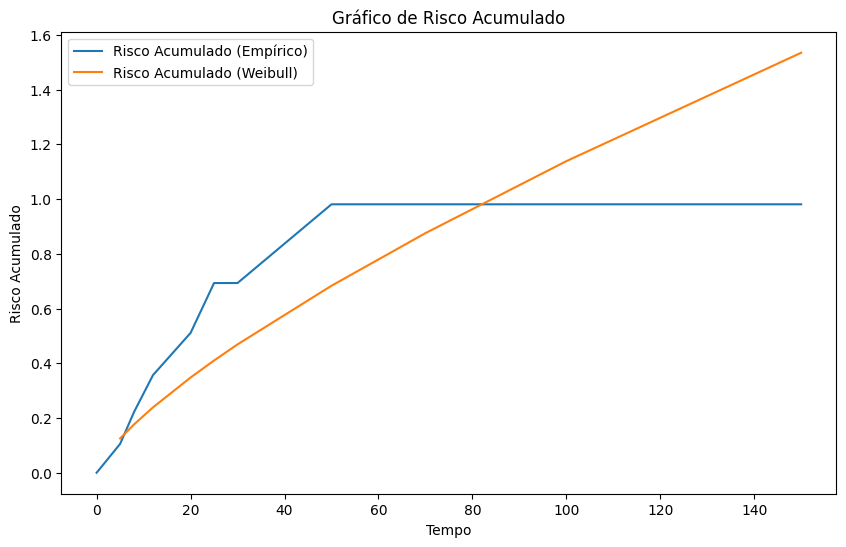

In [ ]:
# Risco acumulado
plt.figure(figsize=(10, 6))
plt.plot(kmf.event_table.index, -np.log(kmf.survival_function_['KM_estimate']), label='Risco Acumulado (Empírico)')
plt.plot(data['time'], weibull_fitter.cumulative_hazard_at_times(data['time']), label='Risco Acumulado (Weibull)')
plt.title('Gráfico de Risco Acumulado')
plt.xlabel('Tempo')
plt.ylabel('Risco Acumulado')
plt.legend()
plt.show()

###Gráfico Log-log para verificar a adequação do modelo

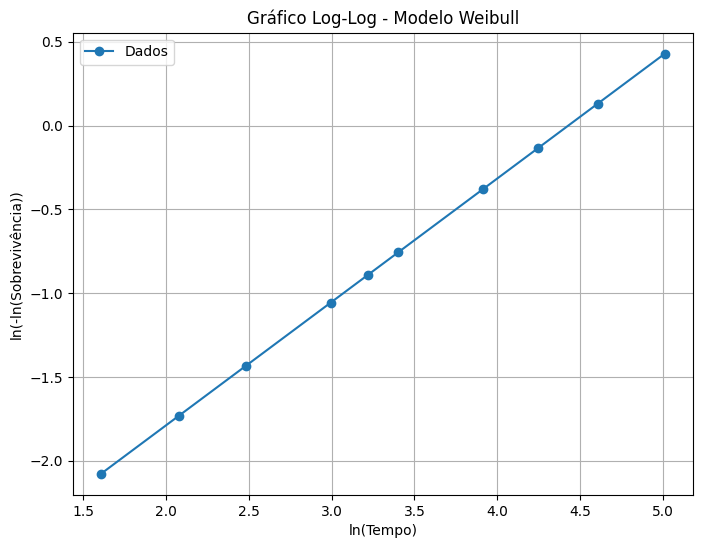

In [ ]:
# Função de sobrevivência ajustada pelo modelo Weibull
sobrevivencia = weibull_fitter.survival_function_at_times(data['time'])

# Transformações para o gráfico log-log
log_tempo = np.log(data['time'])
log_neg_log_sobrevivencia = np.log(-np.log(sobrevivencia))

# Plotar gráfico log-log
plt.figure(figsize=(8, 6))
plt.plot(log_tempo, log_neg_log_sobrevivencia, 'o-', label='Dados')
plt.title('Gráfico Log-Log - Modelo Weibull')
plt.xlabel('ln(Tempo)')
plt.ylabel('ln(-ln(Sobrevivência))')
plt.grid()
plt.legend()
plt.show()

#**Exemplo: Modelo Log-Normal**
##Cenário: Uma empresa registrou os tempos (em horas) até a falha de 10 máquinas industriais. Parte dos dados está censurada porque algumas máquinas ainda não falharam até o final do período de observação.

###Instalando a Biblioteca para análise de Sobrevivência

In [ ]:
pip install lifelines

###Importar as funções

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import probplot
from lifelines import LogNormalFitter

###Inserir os dados

In [ ]:
# Dados simulados: tempos até a falha (em horas)
data = {
    'time': [5, 8, 12, 20, 25, 30, 50, 70, 100, 150],  # Tempos observados
    'event': [1, 1, 1, 1, 1, 0, 1, 0, 0, 0]  # 1 = Falha observada, 0 = Censurado
}

# Criar um DataFrame
df = pd.DataFrame(data)
print(df)

   time  event
0     5      1
1     8      1
2    12      1
3    20      1
4    25      1
5    30      0
6    50      1
7    70      0
8   100      0
9   150      0


###Ajuste do modelo Log-Normal

In [ ]:
# Ajustar o modelo Log-Normal
lognormal_fitter = LogNormalFitter()
lognormal_fitter.fit(df['time'], event_observed=df['event'])

<lifelines.LogNormalFitter:"LogNormal_estimate", fitted with 10 total observations, 4 right-censored observations>

###Parâmetros no Método Log-Normal

In [ ]:
# Exibir os parâmetros do modelo
print("\nParâmetros do modelo Log-Normal:")
print(lognormal_fitter.summary)


Parâmetros do modelo Log-Normal:
           coef  se(coef)  coef lower 95%  coef upper 95%  cmp to         z  \
mu_     3.79749  0.558246        2.703348        4.891632     0.0  6.802538   
sigma_  1.56930  0.498833        0.591605        2.546996     1.0  1.141263   

                   p   -log2(p)  
mu_     1.027916e-11  36.501486  
sigma_  2.537604e-01   1.978461  


###Estimando a Função de Sobrevivência S(t) pelo Log-Normal

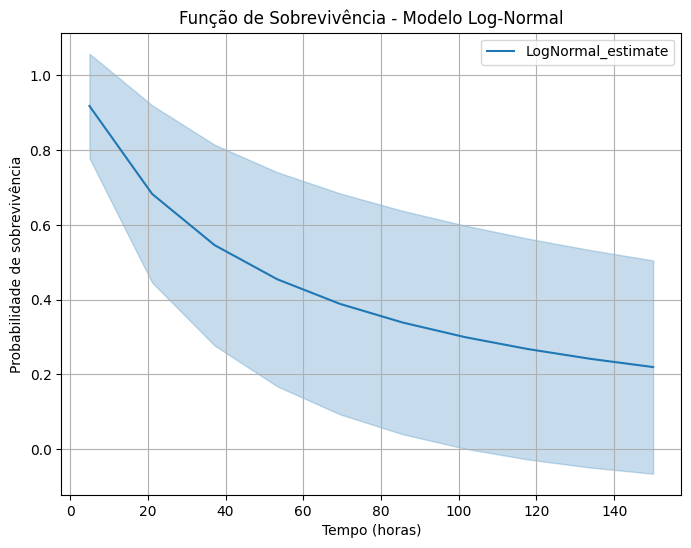

In [ ]:
# Plotar a função de sobrevivência
plt.figure(figsize=(8, 6))
lognormal_fitter.plot_survival_function()
plt.title('Função de Sobrevivência - Modelo Log-Normal')
plt.xlabel('Tempo (horas)')
plt.ylabel('Probabilidade de sobrevivência')
plt.grid()
plt.show()

###Probabilidade Estimada de Sobrevivência no tempo t

In [ ]:
print(lognormal_fitter.survival_function_)

            LogNormal_estimate
5.000000              0.918384
21.111111             0.683123
37.222222             0.545806
53.333333             0.454576
69.444444             0.388851
85.555556             0.338974
101.666667            0.299719
117.777778            0.267977
133.888889            0.241763
150.000000            0.219747


###Função de risco

In [ ]:
# Calcular a função de risco
tempos_plot = np.linspace(0.1, max(df['time']), 100)  # Evitar divisão por zero
risco = lognormal_fitter.hazard_at_times(tempos_plot)

###Gráfico da Função de Risco

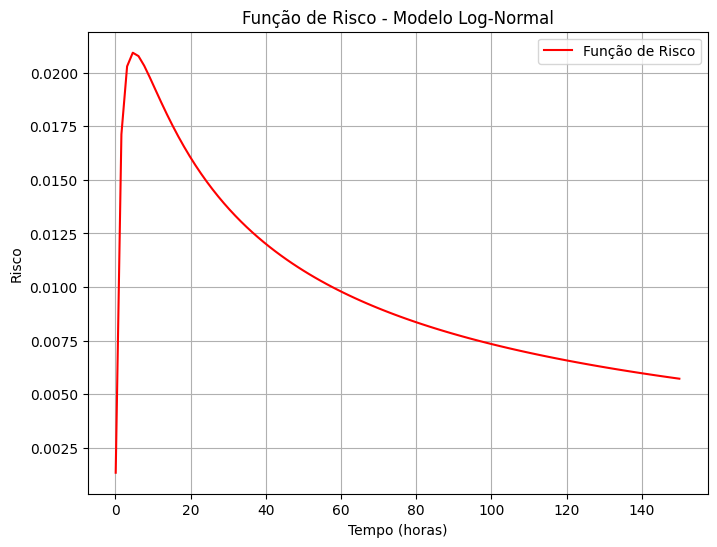

In [ ]:
# Plotar a função de risco
plt.figure(figsize=(8, 6))
plt.plot(tempos_plot, risco, label='Função de Risco', color='red')
plt.title('Função de Risco - Modelo Log-Normal')
plt.xlabel('Tempo (horas)')
plt.ylabel('Risco')
plt.grid()
plt.legend()
plt.show()

###Tempo Médio Esperado de Sobrevivência

In [ ]:
# Tempo médio de sobrevivência (estimado numericamente)
def tempo_medio_lognormal(mu, sigma):
    from scipy.stats import lognorm
    mean = lognorm.mean(s=sigma, scale=np.exp(mu))
    return mean

mu = lognormal_fitter.mu_  # Parâmetro de localização (mu)
sigma = lognormal_fitter.sigma_  # Parâmetro de escala (sigma)

tempo_medio_sobrevivencia = tempo_medio_lognormal(mu, sigma)
print(f"\nTempo médio de sobrevivência: {tempo_medio_sobrevivencia:.2f} horas")



Tempo médio de sobrevivência: 152.76 horas


###Previsão

In [ ]:
# Previsões para tempos específicos
tempos_prev = np.array([10, 20, 40])
previsoes_sobrevivencia = lognormal_fitter.survival_function_at_times(tempos_prev)

print("\nProbabilidade de sobrevivência para tempos específicos:")
for t, p in zip(tempos_prev, previsoes_sobrevivencia):
    print(f"Tempo = {t} horas, Probabilidade de sobrevivência = {p:.2f}")



Probabilidade de sobrevivência para tempos específicos:
Tempo = 10 horas, Probabilidade de sobrevivência = 0.83
Tempo = 20 horas, Probabilidade de sobrevivência = 0.70
Tempo = 40 horas, Probabilidade de sobrevivência = 0.53


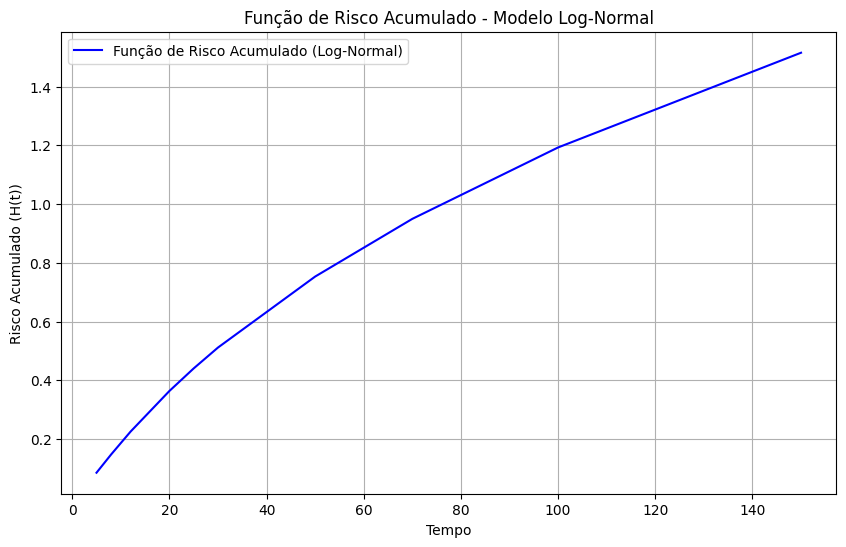

In [ ]:
# Calcular risco acumulado
times = np.linspace(1, 50, 100)  # Intervalo de tempos para avaliar o risco acumulado
cumulative_hazard = lognormal_fitter.cumulative_hazard_at_times(df['time'])

# Plotar o risco acumulado
plt.figure(figsize=(10, 6))
plt.plot(df['time'], cumulative_hazard, label='Função de Risco Acumulado (Log-Normal)', color='blue')
plt.title('Função de Risco Acumulado - Modelo Log-Normal')
plt.xlabel('Tempo')
plt.ylabel('Risco Acumulado (H(t))')
plt.legend()
plt.grid()
plt.show()

###Gráfico Q-Qplot para verificar a adequação do modelo

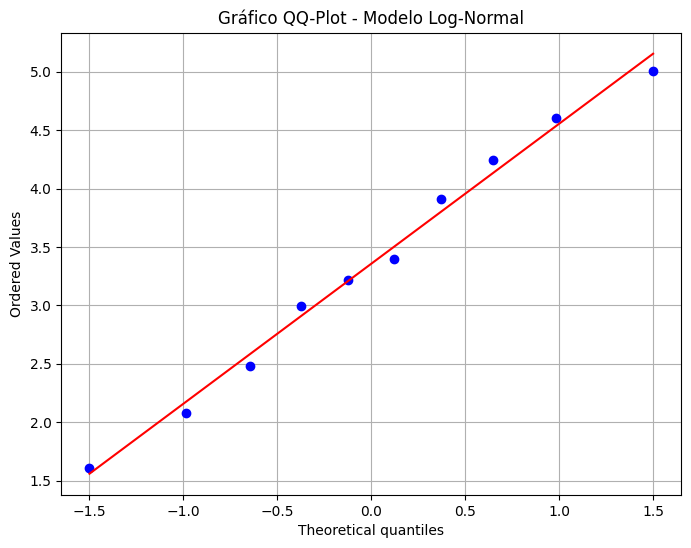

In [ ]:
# Gráfico QQ-Plot para verificar ajuste ao modelo Log-Normal
log_tempos = np.log(df['time'])  # Log-transformação dos tempos
plt.figure(figsize=(8, 6))
probplot(log_tempos, dist="norm", plot=plt)
plt.title("Gráfico QQ-Plot - Modelo Log-Normal")
plt.grid()
plt.show()

###Interpretação gráfica

In [ ]:
print("\nInterpretação Gráfica:")
print("1. A curva da função de sobrevivência mostra a probabilidade de o equipamento sobreviver até um determinado tempo.")
print("2. A função de risco do modelo Log-Normal é não monotônica, podendo aumentar inicialmente e depois diminuir, dependendo dos parâmetros.")
print("3. O gráfico QQ-Plot avalia o quão bem os dados se ajustam à suposição de distribuição Log-Normal. Uma boa aderência é indicada por pontos próximos à linha de referência.")



Interpretação Gráfica:
1. A curva da função de sobrevivência mostra a probabilidade de o equipamento sobreviver até um determinado tempo.
2. A função de risco do modelo Log-Normal é não monotônica, podendo aumentar inicialmente e depois diminuir, dependendo dos parâmetros.
3. O gráfico QQ-Plot avalia o quão bem os dados se ajustam à suposição de distribuição Log-Normal. Uma boa aderência é indicada por pontos próximos à linha de referência.


#Modelo Paramétrico Log-logístico

## Exemplo hipotético de um conjunto de dados onde o risco de infecção pós-cirúrgica aumenta e depois diminui — ou seja, um caso clássico para o modelo log-logístico.

###Simulação dos dados

## Grupo com infecção: 200 observações sendo 34 censuras
## Grupo sem infecção: 200 observações sendo 51 censuras


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import LogLogisticFitter
from lifelines.utils import k_fold_cross_validation

# Simular dados com distribuição log-logística para dois grupos
np.random.seed(42)

# Parâmetros
lambda_A = 10  # Grupo sem infecção
gamma_A = 2.5

lambda_B = 8   # Grupo com infecção (evento mais precoce)
gamma_B = 2.5

n = 200
u_A = np.random.uniform(0, 1, n)
u_B = np.random.uniform(0, 1, n)

tempo_A = lambda_A * ((1 - u_A) / u_A) ** (1 / gamma_A)
tempo_B = lambda_B * ((1 - u_B) / u_B) ** (1 / gamma_B)

evento_A = np.random.binomial(1, 0.8, size=n)
evento_B = np.random.binomial(1, 0.8, size=n)

# Construir DataFrame com grupos
df = pd.DataFrame({
    'tempo': np.concatenate([tempo_A, tempo_B]),
    'evento': np.concatenate([evento_A, evento_B]),
    'grupo': ['sem_infecção'] * n + ['com_infecção'] * n
})

tempo_max = df['tempo'].max()
print(f"Tempo máximo observado no estudo: {tempo_max:.2f} unidades de tempo")

# Separar os grupos
grupo_A = df[df['grupo'] == 'sem_infecção']
grupo_B = df[df['grupo'] == 'com_infecção']

# Ajustar modelos log-logísticos
model_A = LogLogisticFitter()
model_B = LogLogisticFitter()

print(model_A.fit(grupo_A['tempo'], grupo_A['evento'], label='Sem Infecção'))
print(model_B.fit(grupo_B['tempo'], grupo_B['evento'], label='Com Infecção'))






Tempo máximo observado no estudo: 79.84 unidades de tempo
<lifelines.LogLogisticFitter:"Sem Infecção", fitted with 200 total observations, 51 right-censored observations>
<lifelines.LogLogisticFitter:"Com Infecção", fitted with 200 total observations, 34 right-censored observations>


##Função de Sobrevivência

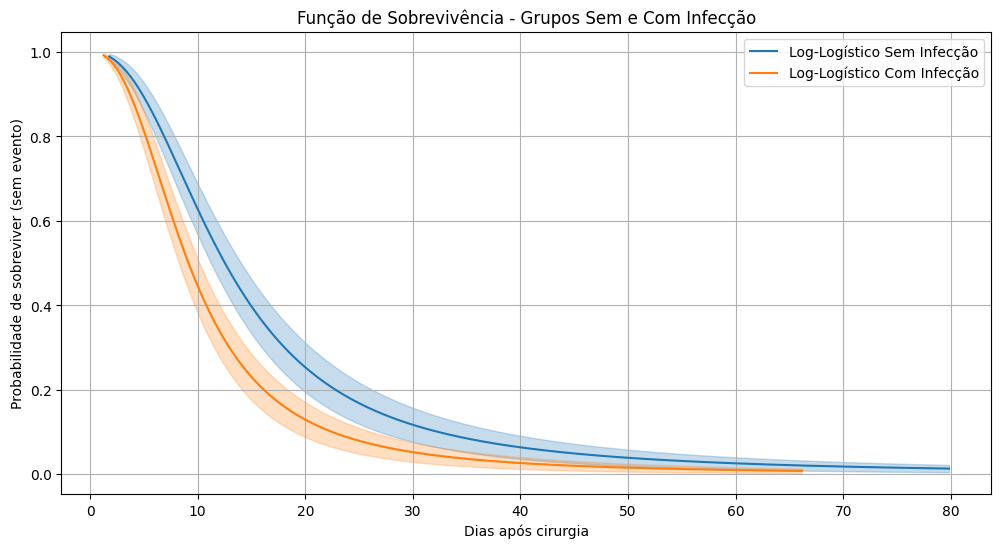

In [33]:
# Plotar função de sobrevivência
plt.figure(figsize=(12, 6))
model_A.plot_survival_function(ci_show=True)
model_B.plot_survival_function(ci_show=True)
plt.title('Função de Sobrevivência - Grupos Sem e Com Infecção')
plt.xlabel('Dias após cirurgia')
plt.ylabel('Probabilidade de sobreviver (sem evento)')
plt.grid(True)
plt.legend()
plt.show()


##Teste de Log-rank para comparar curvas de sobrevivência

In [34]:
from lifelines.statistics import logrank_test

# Teste de Log-Rank para comparar a função de sobrevivência dos dois grupos
resultado_logrank = logrank_test(
    grupo_A['tempo'], grupo_B['tempo'],
    event_observed_A=grupo_A['evento'],
    event_observed_B=grupo_B['evento']
)

print(f'Estatística do teste de Log-Rank: {resultado_logrank.test_statistic:.4f}')
print(f'p-valor: {resultado_logrank.p_value:.4f}')

if resultado_logrank.p_value < 0.05:
    print("Rejeita-se a hipótese nula: as curvas de sobrevivência são diferentes.")
else:
    print("Não se rejeita a hipótese nula: não há evidência para diferenças entre as curvas.")


Estatística do teste de Log-Rank: 12.8647
p-valor: 0.0003
Rejeita-se a hipótese nula: as curvas de sobrevivência são diferentes.


##Função de Risco

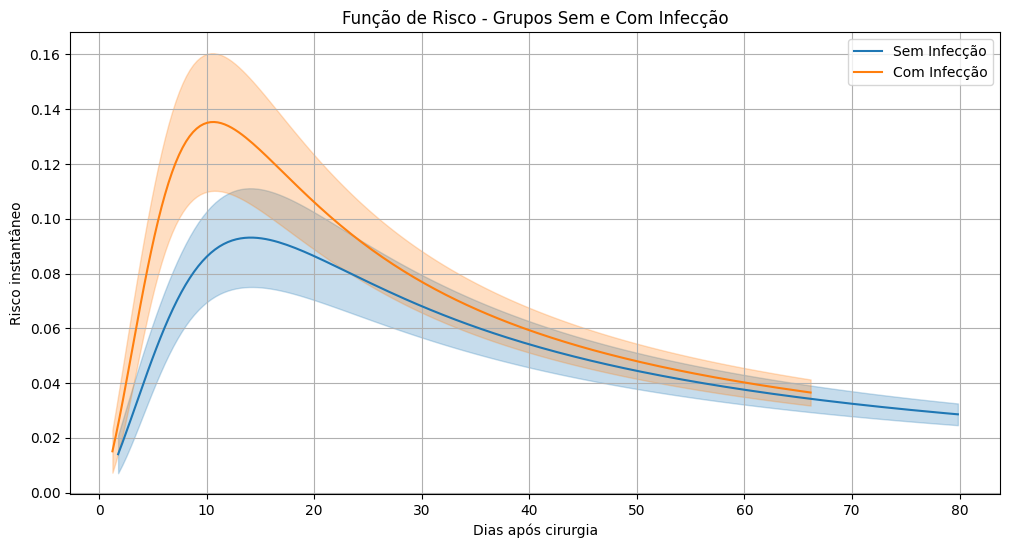

In [36]:
# Plotar função de risco
plt.figure(figsize=(12, 6))
model_A.plot_hazard(label='Sem Infecção', ci_show=True)
model_B.plot_hazard(label='Com Infecção', ci_show=True)
plt.title('Função de Risco - Grupos Sem e Com Infecção')
plt.xlabel('Dias após cirurgia')
plt.ylabel('Risco instantâneo')
plt.grid(True)
plt.legend()
plt.show()

#Verificação da Qualidade do Ajuste do Modelo Log-logistico

##Sobreposição das curvas de Kaplan-Meier versus Log-logístico

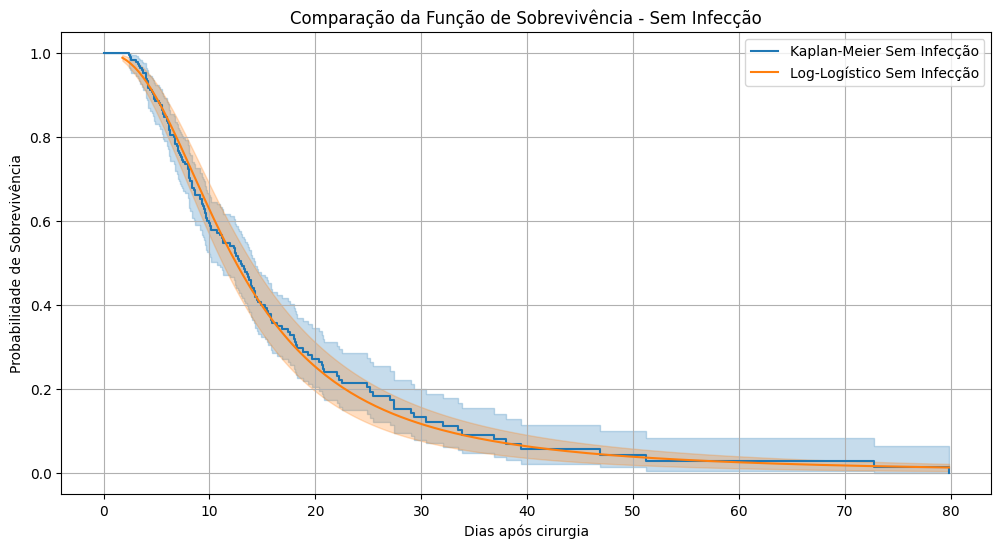

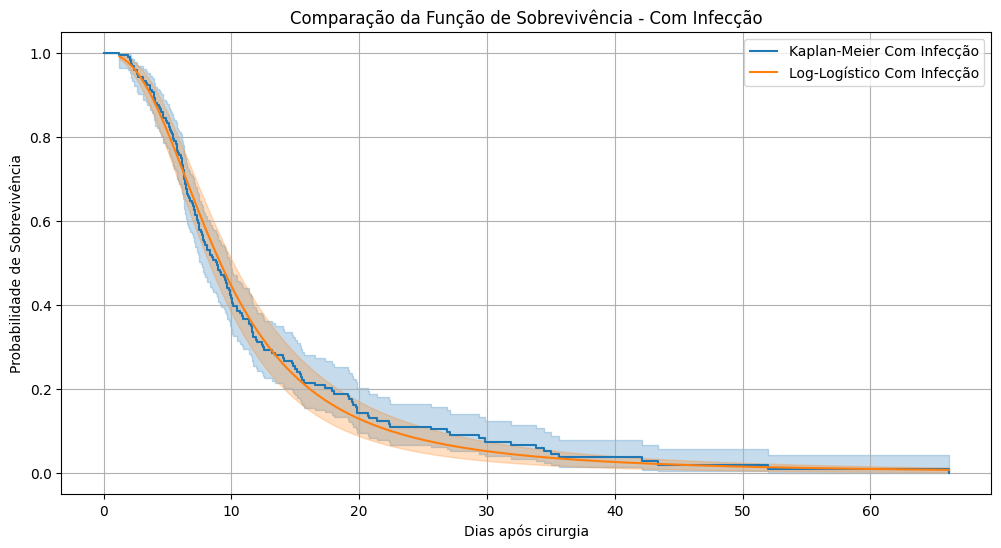

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import LogLogisticFitter, KaplanMeierFitter



# Ajustar Kaplan-Meier
kmf_A = KaplanMeierFitter().fit(grupo_A['tempo'], grupo_A['evento'], label='Kaplan-Meier Sem Infecção')
kmf_B = KaplanMeierFitter().fit(grupo_B['tempo'], grupo_B['evento'], label='Kaplan-Meier Com Infecção')

# Plotar comparação para SEM infecção
plt.figure(figsize=(12,6))
kmf_A.plot_survival_function(ci_show=True)
model_A.plot_survival_function(ci_show=True)
plt.title('Comparação da Função de Sobrevivência - Sem Infecção')
plt.xlabel('Dias após cirurgia')
plt.ylabel('Probabilidade de Sobrevivência')
plt.legend()
plt.grid(True)
plt.show()

# Plotar comparação para COM infecção
plt.figure(figsize=(12,6))
kmf_B.plot_survival_function(ci_show=True)
model_B.plot_survival_function(ci_show=True)
plt.title('Comparação da Função de Sobrevivência - Com Infecção')
plt.xlabel('Dias após cirurgia')
plt.ylabel('Probabilidade de Sobrevivência')
plt.legend()
plt.grid(True)
plt.show()


O que observar:

Se as curvas do modelo Log-Logístico estão próximas das do Kaplan-Meier, o ajuste é bom.

Diferenças grandes podem indicar má adequação do modelo.

# Significância dos parametros do modelo

In [66]:
model_A.summary


,coef,se(coef),coef lower 95%,coef upper 95%,cmp to,z,p,-log2(p)
alpha_,12.535314,0.713690,11.136507,13.934120,1.0,16.162921,9.209335e-59,192.790661
beta_,2.313339,0.154416,2.010688,2.615989,1.0,8.505187,1.813027e-17,55.614377


In [67]:
model_B.summary

,coef,se(coef),coef lower 95%,coef upper 95%,cmp to,z,p,-log2(p)
alpha_,9.148444,0.486076,8.195752,10.101136,1.0,16.763711,4.496574e-63,207.112644
beta_,2.436802,0.155712,2.131612,2.741992,1.0,9.227301,2.775369e-20,64.965882


#Tempo médio de vida

In [68]:
import numpy as np

# Obter os parâmetros estimados do modelo
lambda_A_est = np.exp(model_A.params_['alpha_'])
gamma_A_est = model_A.params_['beta_']

lambda_B_est = np.exp(model_B.params_['alpha_'])
gamma_B_est = model_B.params_['beta_']

# Calcular tempo médio de vida teórico
def tempo_medio_loglogistico(lambd, gamma):
    if gamma <= 1:
        return np.nan  # média não existe
    return lambd * (np.pi / gamma) / np.sin(np.pi / gamma)

media_A = tempo_medio_loglogistico(lambda_A_est, gamma_A_est)
media_B = tempo_medio_loglogistico(lambda_B_est, gamma_B_est)

print(f"Tempo médio de vida (sem infecção): {media_A:.2f} dias")
print(f"Tempo médio de vida (com infecção): {media_B:.2f} dias")


Tempo médio de vida (sem infecção): 386218.49 dias
Tempo médio de vida (com infecção): 12615.26 dias


Tempo médio sem infecção > tempo com infecção

###Razão entre os tempos médio de vida

In [69]:
razão=media_A /media_B
print(razão)

30.61517630741


Interpretação:

O tempo médio de vida no grupo sem infecção é aproximadamente 30,6 vezes maior do que no grupo com infecção.

Isso reflete um impacto muito expressivo da infecção pós-cirúrgica na redução da sobrevida — e reforça o que o gráfico de razão de risco também mostrou: diferença acentuada entre os grupos ao longo do tempo.

### Razão de risco (hazard ratio)

In [70]:
def loglogistic_hazard(t, lambd, gamma):
    numerator = (gamma / lambd) * ( (t / lambd) ** (gamma - 1) )
    denominator = 1 + (t / lambd) ** gamma
    return numerator / denominator

# Calcular hazard no tempo mediano do grupo A
t_median_A = model_A.median_survival_time_

hazard_A = loglogistic_hazard(t_median_A, lambda_A_est, gamma_A_est)
hazard_B = loglogistic_hazard(t_median_A, lambda_B_est, gamma_B_est)

# Razão de risco (hazard ratio)
hazard_ratio = hazard_B / hazard_A

print(f"Risco instantâneo (sem infecção) em t={t_median_A:.2f}: {hazard_A:.4f}")
print(f"Risco instantâneo (com infecção) em t={t_median_A:.2f}: {hazard_B:.4f}")
print(f"Razão de risco (com / sem infecção): {hazard_ratio:.4f}")


Risco instantâneo (sem infecção) em t=12.54: 0.0000
Risco instantâneo (com infecção) em t=12.54: 0.0000
Razão de risco (com / sem infecção): 1175.7416


Interpretação:

HR > 1 → o grupo com infecção tem maior risco instantâneo no tempo analisado.

HR < 1 → menor risco que o grupo sem infecção naquele tempo.

Esse valor muda com o tempo, pois o modelo log-logístico tem risco não constante.

##Gráfico da razão de risco

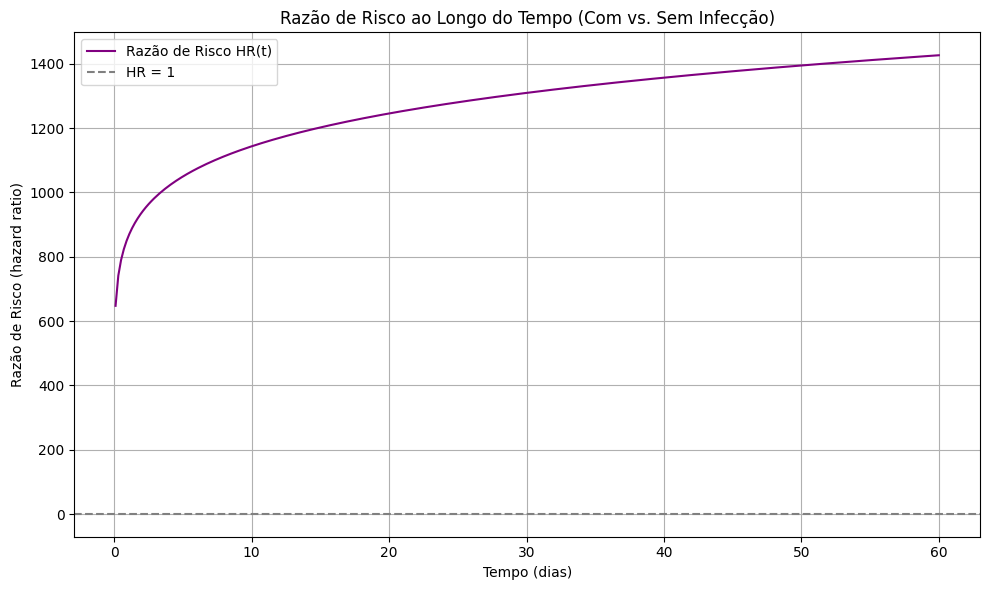

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Função de risco log-logística
def loglogistic_hazard(t, lambd, gamma):
    num = (gamma / lambd) * ( (t / lambd) ** (gamma - 1) )
    den = 1 + (t / lambd) ** gamma
    return num / den

# Vetor de tempos
tempos = np.linspace(0.1, 60, 300)  # evitar t=0 para não dividir por zero

# Risco para cada grupo
hazard_A_t = loglogistic_hazard(tempos, lambda_A_est, gamma_A_est)
hazard_B_t = loglogistic_hazard(tempos, lambda_B_est, gamma_B_est)

# Razão de risco ao longo do tempo
HR_t = hazard_B_t / hazard_A_t

# Plotar razão de risco
plt.figure(figsize=(10, 6))
plt.plot(tempos, HR_t, color='purple', label='Razão de Risco HR(t)')
plt.axhline(1, color='gray', linestyle='--', label='HR = 1')
plt.xlabel('Tempo (dias)')
plt.ylabel('Razão de Risco (hazard ratio)')
plt.title('Razão de Risco ao Longo do Tempo (Com vs. Sem Infecção)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


HR(t) > 1 o tempo todo

Isso significa que:

Em todos os momentos analisados, o risco instantâneo de morte (ou falha, ou evento) é consistentemente maior no grupo com infecção do que no grupo sem infecção.

A infecção pós-cirúrgica aumenta significativamente o risco de morte ao longo do tempo, e esse risco cresce de forma acentuada conforme os dias passam após a cirurgia.